In [1]:
from matplotlib import pyplot as plt
from math import log2
import numpy as np
import re

In [2]:
data_dir = '/lustre/scratch127/qpg/jc59/out/tangle'

In [3]:
def data_entry(solver):
    for kmer in ['k501', 'k301', 'k201', 'k101', 'k81', 'sim_k71', 'sim_k61','sim_k51','sim_k41']:
        filename=f'{data_dir}/{solver}.ddDapMeze1.MT.{kmer}.utg.final.gfa.compiled.txt'
        try:
            f = open(filename, 'r')
            line = f.readline()
            matches = re.findall(r'\[\d+, \d+.?\d*\]', line)
            matches_array = [[int(x.split(',')[0][1:]), float(x.split(',')[1][0:-1])] for x in matches]
            np.save(f'{data_dir}/data.{solver}.{kmer}', matches_array)
        except FileNotFoundError:
            pass

In [4]:
data_entry('mqlib')
data_entry('dwave')
data_entry('gurobi')

In [6]:
# dwave_data_k61 = np.load(f'{data_dir}/data.dwave.sim_k61.npy')
# dwave_data_k71 = np.load(f'{data_dir}/data.dwave.sim_k71.npy')
dwave_data_k101 = np.load(f'{data_dir}/data.dwave.k101.npy')
dwave_data_k201 = np.load(f'{data_dir}/data.dwave.k201.npy')
dwave_data_k301 = np.load(f'{data_dir}/data.dwave.k301.npy')
dwave_data_k501 = np.load(f'{data_dir}/data.dwave.k501.npy')


mqlib_data_k41 = np.load(f'{data_dir}/data.mqlib.sim_k41.npy')
# mqlib_data_k51 = np.load(f'{data_dir}/data.mqlib.sim_k51.npy')
# mqlib_data_k61 = np.load(f'{data_dir}/data.mqlib.sim_k61.npy')
# mqlib_data_k71 = np.load(f'{data_dir}/data.mqlib.sim_k71.npy')
mqlib_data_k101 = np.load(f'{data_dir}/data.mqlib.k101.npy')
mqlib_data_k201 = np.load(f'{data_dir}/data.mqlib.k201.npy')
mqlib_data_k301 = np.load(f'{data_dir}/data.mqlib.k301.npy')
mqlib_data_k501 = np.load(f'{data_dir}/data.mqlib.k501.npy')

# gurobi_data_k41 = np.load(f'{data_dir}/data.gurobi.sim_k41.npy')
# gurobi_data_k51 = np.load(f'{data_dir}/data.gurobi.sim_k51.npy')
# gurobi_data_k61 = np.load(f'{data_dir}/data.gurobi.sim_k61.npy')
# gurobi_data_k71 = np.load(f'{data_dir}/data.gurobi.sim_k71.npy')
gurobi_data_k101 = np.load(f'{data_dir}/data.gurobi.k101.npy')
gurobi_data_k201 = np.load(f'{data_dir}/data.gurobi.k201.npy')
gurobi_data_k301 = np.load(f'{data_dir}/data.gurobi.k301.npy')
gurobi_data_k501 = np.load(f'{data_dir}/data.gurobi.k501.npy')

In [22]:
times, counts = np.unique(dwave_data_k101[:,0], return_counts=True)
data, counts = np.unique(dwave_data_k101[:,1], return_counts=True)
print(data, counts)

times, counts = np.unique(mqlib_data_k101[:,0], return_counts=True)
data, counts = np.unique(mqlib_data_k101[:,1], return_counts=True)
print(data, counts)

[ 4.  5.  6.  7.  8.  9. 10. 11. 12.] [1 4 5 5 5 4 4 3 4]
[ 3.  4.  5.  7. 10. 12. 13. 14.] [11  4 10  5  5  7  1  2]


In [14]:
def plot_qubo_data(*args):
    fig, ax = plt.subplots()
    
    min_val = min(np.min(arg[:, 1]) for arg in args) - 1
    colours = ['tab:blue', 'tab:orange', 'tab:green']
    names = ['D-Wave', 'Gurobi', 'MQLib']
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data, return_counts=True, axis=0)
        times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
        ax.scatter(unique_data[:, 0] / 60, unique_data[:, 1] - min_val, s=marker_sizes, c=colours[idx], label=names[idx], alpha=0.5)
        
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy $-$ minEnergy $+ 1$')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), labelspacing=3)
    ax.grid(True, which="major", axis='y')
    fig.tight_layout()
    plt.show()

In [ ]:
plot_qubo_data(dwave_data_k101, gurobi_data_k201, mqlib_data_k201)

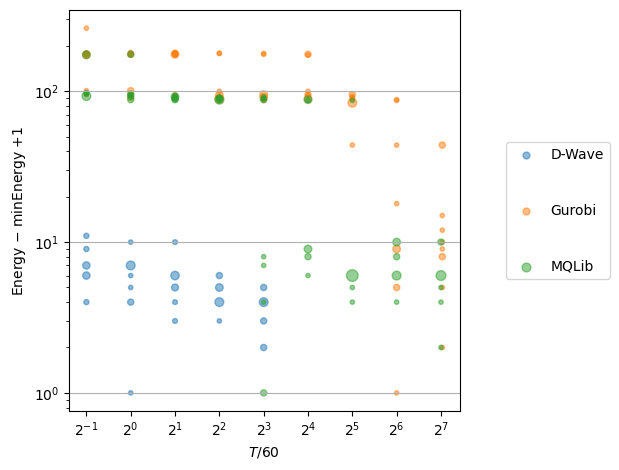

In [15]:
plot_qubo_data(dwave_data_k71, gurobi_data_k71, mqlib_data_k71)

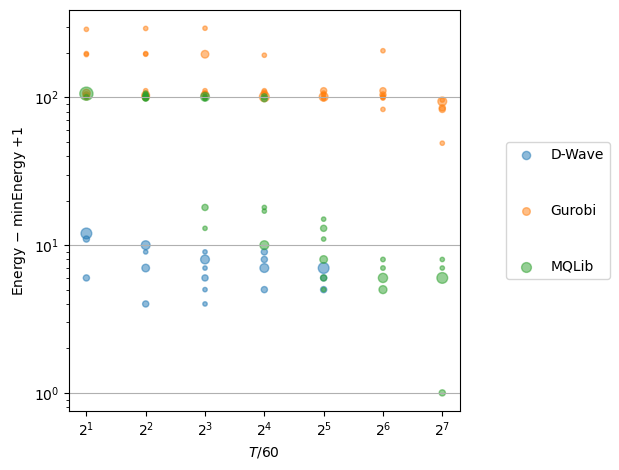

In [16]:
plot_qubo_data(dwave_data_k61, gurobi_data_k61, mqlib_data_k61)

In [ ]:
def solver_histograms(title: str, data_tuple: tuple):
    all_times = set()
    for data in data_tuple:
        all_times = all_times.union(set(data[:, 0]))
    all_times = sorted(list(all_times))
    
    all_energies = set()
    for data in data_tuple:
        all_energies = all_energies.union(set(data[:, 1]))
    all_energies = sorted(list(all_energies))
    
    bins = np.arange(min(all_energies), max(all_energies) + 2)
    
    names = ['MQLib', 'Gurobi', 'D-Wave']
     
    fig, axs = plt.subplots(nrows=1, ncols=len(all_times), sharex=True)
    fig.subplots_adjust(left=-1, right=0)
    
    for idx, time in enumerate(all_times):
        energies = [data[data[:, 0] == time][:, 1] for data in data_tuple]
        ax = axs[idx]
        ax.hist(energies, bins, orientation='horizontal', align='left', rwidth=0.4)
        ax.set_xlabel(fr'$T = {int(time)}$')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.get_xaxis().set_ticks([])
        if not idx == 0:
            ax.get_yaxis().set_ticks([])
            # ax.spines['left'].set_visible(False)
     
    axs[0].set_ylabel(r'Energy')
    fig.legend(names, loc='center left', bbox_to_anchor=(1., 0.5), title='Solver')
    fig.tight_layout()
    st = plt.suptitle(title)
    st.set_y(0.95)
    fig.subplots_adjust(top=0.85)   
    plt.show()

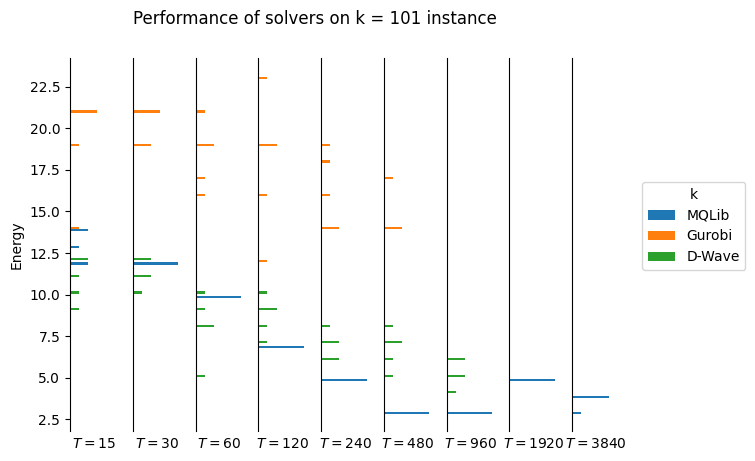

In [8]:
solver_histograms(
    'Performance of solvers on k = 101 instance', 
    (mqlib_data_k101, gurobi_data_k101, dwave_data_k101)
)

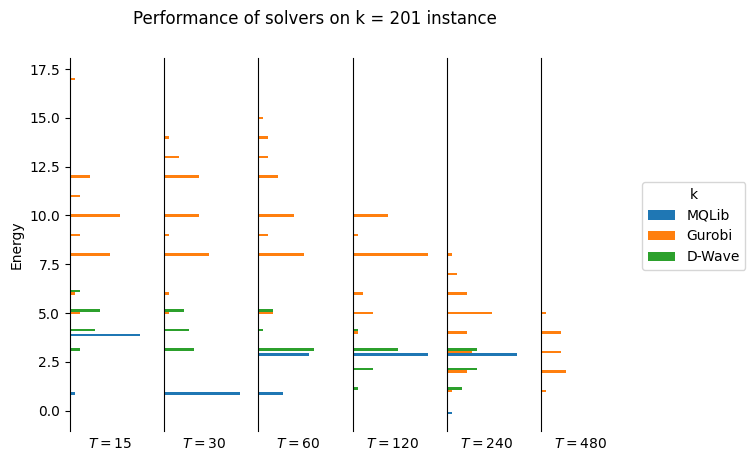

In [10]:
solver_histograms(
    'Performance of solvers on k = 201 instance', 
    (mqlib_data_k201, gurobi_data_k201, dwave_data_k201)
)

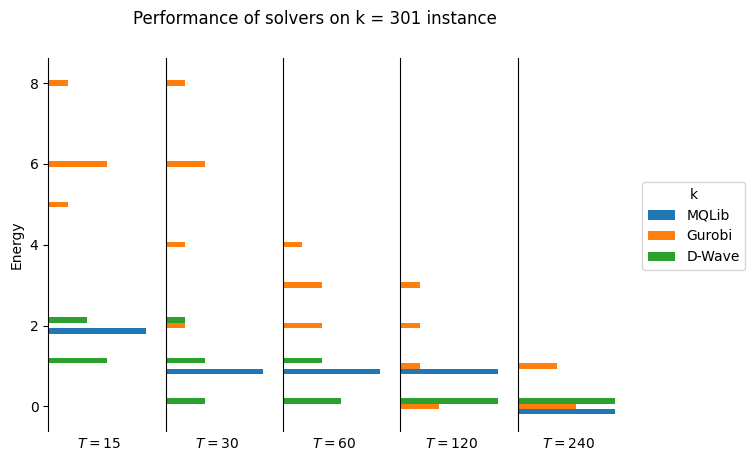

In [24]:
solver_histograms(
    'Performance of solvers on k = 301 instance', 
    (mqlib_data_k301, gurobi_data_k301, dwave_data_k301)
)